# Day 4 — Deep Learning Engineering

## Note 4.3 — Memory, Batch Size and Precision

### How to read this note

This note answers one question:

> **Will this run fit in the memory I have, and what do I do when it does not?**

Every model in this course so far has been small enough that memory never came up. That ends on Day 8, when you adapt a pretrained model, and on Day 9, when you serve one. The first thing most people meet there is a wall of red text ending in *out of memory*.

The cure is not a bigger machine. It is being able to say, **before** you press run, roughly how many bytes the run needs and which setting moves that number.

Almost everything here is arithmetic that does not care what machine you are on. A number takes four bytes on a laptop and four bytes on an eighty-thousand-dollar GPU. So Sections 1 to 7 are measured on CPU, and every reader gets the same numbers. Section 8 needs an NVIDIA GPU and skips itself politely if there is not one. Section 9 is for Apple Silicon Macs.

Nothing here is imported from another notebook.

### Learning goal and outcome

**Goal:** be able to predict a run's memory before starting it, and to work an out-of-memory error methodically instead of guessing.

The four things that take up memory while training:

```text
   weights          the model itself
      +
   gradients        one number per weight
      +
   optimizer state  AdamW keeps two more numbers per weight
      +
   activations      the intermediate results, which grow with batch size
```

**Outcome:** by the end you should be able to:

- say roughly how much memory a model of a given size needs to train, before running it;
- explain why training needs about four times what the model itself takes;
- explain fp32, fp16 and bf16 in terms of range and precision, and say which needs a loss scaler;
- measure how activation memory and speed respond to batch size;
- use gradient accumulation to get a big effective batch in small memory;
- put `autocast` in the right place, and recognise the damage when it is in the wrong one;
- work through an out-of-memory error in a fixed order, cheapest fix first.

### Objectives

By the end of this note you should be able to:

- count the bytes in a tensor from its shape and its type;
- explain what an optimizer keeps per weight, and why that triples the model's memory;
- estimate the memory for a 7-billion-parameter model in three different situations;
- read `torch.finfo` and say what a number format can and cannot hold;
- measure activation memory with a forward hook;
- explain why throughput stops improving past a certain batch size;
- show that gradient accumulation matches a big batch, and name the one layer it breaks;
- list the out-of-memory fixes in order of what they cost you.

### Datasets used

**Mostly none.** Memory depends on the shape of the tensors, not on what the numbers mean, so most measurements here use the Day 3 network with random numbers of a controlled size. That keeps the cells fast and the numbers clean.

**Section 7 is the exception.** It trains on **UCI Bank Marketing**, the file from Notes 4.1 and 4.2, to check that reducing precision does not damage a result you already know.

### Table of contents

1. [Where the bytes go](#s1)
2. [Counting before you run](#s2)
3. [fp32, fp16 and bf16](#s3)
4. [Activations and batch size](#s4)
5. [Speed and batch size](#s5)
6. [Gradient accumulation](#s6)
7. [Mixed precision, and where to put it](#s7)
8. [On an NVIDIA GPU: VRAM, running out, and recovering](#s8)
9. [On an Apple Silicon Mac](#s9)
10. [The out-of-memory playbook](#s10)

### Runtime budget

| Section | Approximate time |
|---|---|
| Sections 1–4 | under 10 s |
| Section 5 — speed measurements | ~6 s |
| Section 6 | under 5 s |
| Section 7 — four short training runs | ~40 s |
| Sections 8–10 | seconds, or skipped |

Under **two minutes** in total, plus the data download in Section 7 if you have not run 4.1 or 4.2 in this folder.

### Environment setup

In [1]:
# pip install torch==2.14.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 matplotlib==3.10.8

import gc
import io
import os
import platform
import time
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

pd.set_option("display.width", 140)

MB = 1024 ** 2          # a megabyte, in bytes
GB = 1024 ** 3          # a gigabyte, in bytes

print("torch  ", torch.__version__)
print("machine", platform.machine())
print("CPU threads torch will use:", torch.get_num_threads())

torch   2.14.0+cpu
machine x86_64
CPU threads torch will use: 1


In [2]:
if torch.cuda.is_available():
    DEVICE, ACCELERATOR = torch.device("cuda"), torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE, ACCELERATOR = torch.device("mps"), "Apple Silicon GPU (MPS)"
else:
    DEVICE, ACCELERATOR = torch.device("cpu"), "none"

print(f"accelerator found : {ACCELERATOR}")
print(f"sections 1-7      : run on CPU, so everyone gets the same numbers")
print(f"section 8 (NVIDIA): {'runs here' if DEVICE.type == 'cuda' else 'skipped on this machine'}")
print(f"section 9 (Apple) : {'runs here' if DEVICE.type == 'mps' else 'skipped on this machine'}")

accelerator found : none
sections 1-7      : run on CPU, so everyone gets the same numbers
section 8 (NVIDIA): skipped on this machine
section 9 (Apple) : skipped on this machine


<a id="s1"></a>
## 1. Where the bytes go

Start with the smallest possible question: how much memory does one tensor take?

A tensor holds numbers of one type. The commonest type is `float32`, which uses **4 bytes** per number. So the memory is simply "how many numbers" times "bytes per number". PyTorch will tell you both.

In [3]:
example = torch.zeros(1000, 50)                 # 1,000 rows of 50 numbers

print("shape                :", tuple(example.shape))
print("how many numbers     :", example.numel())
print("bytes per number     :", example.element_size())
print("total bytes          :", example.numel() * example.element_size())
print("in megabytes         :", round(example.numel() * example.element_size() / MB, 3))

shape                : (1000, 50)
how many numbers     : 50000
bytes per number     : 4
total bytes          : 200000
in megabytes         : 0.191


That is the whole arithmetic. Everything else in this note is that multiplication applied to different things.

Now, what does a *training run* hold? Four kinds of tensor. Three of them scale with the size of the **model** and one scales with the size of the **batch**:

- **parameters** — the weights themselves, the thing you are training;
- **gradients** — one per parameter, saying how much that parameter contributed to the error. So, a second copy of the model;
- **optimizer state** — extra numbers the optimizer keeps between steps. Plain SGD keeps none. SGD with momentum keeps one per parameter. Adam and AdamW keep **two**;
- **activations** — the intermediate results of the forward pass, kept because the backward pass needs them.

Rather than take that on trust, measure it on the Day 3 network.

In [4]:
def build_mlp(n_inputs=50, hidden=(64, 32)):
    """The Day 3 network shape: inputs -> hidden layers -> one output."""
    layers, previous = [], n_inputs
    for width in hidden:
        layers += [nn.Linear(previous, width), nn.ReLU()]
        previous = width
    layers.append(nn.Linear(previous, 1))
    return nn.Sequential(*layers)

torch.manual_seed(0)
model = build_mlp()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_function = nn.BCEWithLogitsLoss()

batch_x = torch.randn(256, 50)
batch_y = (torch.rand(256, 1) > 0.5).float()

loss_function(model(batch_x), batch_y).backward()    # creates the gradients
optimizer.step()                                     # creates the optimizer state

def total_bytes(tensors):
    return sum(t.numel() * t.element_size() for t in tensors if torch.is_tensor(t))

parameter_bytes = total_bytes(model.parameters())
gradient_bytes = total_bytes([p.grad for p in model.parameters()])
state_bytes = total_bytes([v for entry in optimizer.state.values() for v in entry.values()])

print(f"parameters      : {sum(p.numel() for p in model.parameters()):>7,} numbers  {parameter_bytes:>8,} bytes")
print(f"gradients       : {'':>7}  {gradient_bytes:>8,} bytes   ({gradient_bytes / parameter_bytes:.2f} x parameters)")
print(f"AdamW state     : {'':>7}  {state_bytes:>8,} bytes   ({state_bytes / parameter_bytes:.2f} x parameters)")
print(f"total so far    : {'':>7}  {parameter_bytes + gradient_bytes + state_bytes:>8,} bytes")

parameters      :   5,377 numbers    21,508 bytes
gradients       :            21,508 bytes   (1.00 x parameters)
AdamW state     :            43,040 bytes   (2.00 x parameters)
total so far    :            86,056 bytes


Gradients cost exactly what the parameters cost, as promised. AdamW costs **twice** the parameters. Look at what it is keeping:

In [5]:
for parameter, stored in optimizer.state.items():
    print("per parameter tensor, AdamW keeps:",
          {name: (tuple(value.shape) if torch.is_tensor(value) else value) for name, value in stored.items()})
    break

per parameter tensor, AdamW keeps: {'step': (), 'exp_avg': (64, 50), 'exp_avg_sq': (64, 50)}


`exp_avg` is a running average of recent gradients and `exp_avg_sq` is a running average of their squares. Both are the same shape as the weights, so both cost the same as the whole model.

**That is the rule to remember: training with AdamW needs about four times the memory of the model itself**, before a single activation is stored. One copy of weights, one of gradients, two of optimizer state.

That single factor of four explains a lot of Day 8. It is why fully fine-tuning a large model is out of reach on ordinary hardware, and why LoRA — which freezes almost all the weights, so they need no gradient and no optimizer state — changes what is possible rather than merely what is convenient.

**Questions to sit with**

1. You swap AdamW for plain SGD with no momentum. What does the "four times" become?
2. Which of the four kinds of tensor does *inference* need, and which does it not?

<a id="s2"></a>
## 2. Counting before you run

The arithmetic above works for any model, so you can estimate a model you have never run, from its parameter count alone.

The function below does that. Its arguments:

- `n_parameters` — how many weights the model has;
- `precision` — how many bytes each number takes (Section 3 explains the choices);
- `optimizer` — how many extra copies it keeps per parameter;
- `trainable` — the share of parameters you are actually training. 1.0 means all of them; LoRA makes this tiny.

Activations are not included; Section 4 adds them.

In [6]:
BYTES_PER_NUMBER = {"fp32": 4, "fp16": 2, "bf16": 2, "int8": 1}
OPTIMIZER_COPIES = {"none (inference)": 0, "sgd": 0, "sgd with momentum": 1, "adam or adamw": 2}

def training_memory(n_parameters, precision="fp32", optimizer="adam or adamw", trainable=1.0):
    """Bytes for weights + gradients + optimizer state."""
    size = BYTES_PER_NUMBER[precision]
    if optimizer == "none (inference)":
        trainable = 0.0                       # no backward pass, so no gradients at all
    weights = n_parameters * size
    gradients = n_parameters * trainable * size
    state = n_parameters * trainable * OPTIMIZER_COPIES[optimizer] * size
    return {"weights": weights, "gradients": gradients,
            "optimizer state": state, "total": weights + gradients + state}

# check it against what we measured by hand in Section 1
estimate = training_memory(5377)
print("estimated total bytes for the Day 3 network:", int(estimate["total"]))
print("measured  total bytes in Section 1         :", parameter_bytes + gradient_bytes + state_bytes)

estimated total bytes for the Day 3 network: 86032
measured  total bytes in Section 1         : 86056


The estimate is a few bytes under the measurement, because AdamW also keeps a tiny step counter per tensor. Close enough for planning.

Now use it on models you would not want to run by accident. A **7B model** means seven billion parameters, the size of a small open-weights language model like the ones Day 8 fine-tunes.

In [7]:
rows = []
for label, count, extra in [
    ("Day 3 network (5,377)", 5_377, {}),
    ("wide network (1.1M)", 1_102_849, {}),
    ("BERT-base (110M)", 110_000_000, {}),
    ("7B, fp32, AdamW", 7_000_000_000, {}),
    ("7B, fp16 weights, AdamW", 7_000_000_000, {"precision": "fp16"}),
    ("7B, inference only, fp16", 7_000_000_000, {"precision": "fp16", "optimizer": "none (inference)"}),
    ("7B, LoRA: 0.2% trainable", 7_000_000_000, {"precision": "fp16", "trainable": 0.002}),
]:
    rows.append({"model": label, **training_memory(count, **extra)})

table = pd.DataFrame(rows).set_index("model")
table["total (MB)"] = (table["total"] / MB).round(2)
for column in ["weights", "gradients", "optimizer state", "total"]:
    table[column] = (table[column] / GB).round(3)
print(table.rename(columns=lambda c: f"{c} (GB)" if c != "total (MB)" else c).to_string())

                          weights (GB)  gradients (GB)  optimizer state (GB)  total (GB)  total (MB)
model                                                                                               
Day 3 network (5,377)            0.000           0.000                 0.000       0.000        0.08
wide network (1.1M)              0.004           0.004                 0.008       0.016       16.83
BERT-base (110M)                 0.410           0.410                 0.820       1.639     1678.47
7B, fp32, AdamW                 26.077          26.077                52.154     104.308   106811.52
7B, fp16 weights, AdamW         13.039          13.039                26.077      52.154    53405.76
7B, inference only, fp16        13.039           0.000                 0.000      13.039    13351.44
7B, LoRA: 0.2% trainable        13.039           0.026                 0.052      13.117    13431.55


Read those 7B rows against real hardware. A free Colab T4 has about 15 GB of GPU memory. A good consumer GPU has 24 GB. An A100 or H100 in a data centre has 80 GB.

- **Fully fine-tuning a 7B model in fp32 with AdamW: 104 GB**, before any activations. That does not fit on any single GPU you are likely to touch.
- **Same, with fp16 weights: 52 GB.** Still no.
- **Loading it just to make predictions, in fp16: 13 GB.** That fits on a free Colab GPU, which is why *running* a 7B model is routine while *training* one is not.
- **LoRA, training 0.2% of the parameters: 13 GB plus 0.08 GB.** The gradients and optimizer state almost vanish, and what is left is the frozen model itself. Quantise those frozen weights to 4 bits — that is QLoRA, on Day 8 — and even that shrinks.

This table is also how you answer "will this fit?" in a code review, without booking a GPU to find out.

<div align="center">

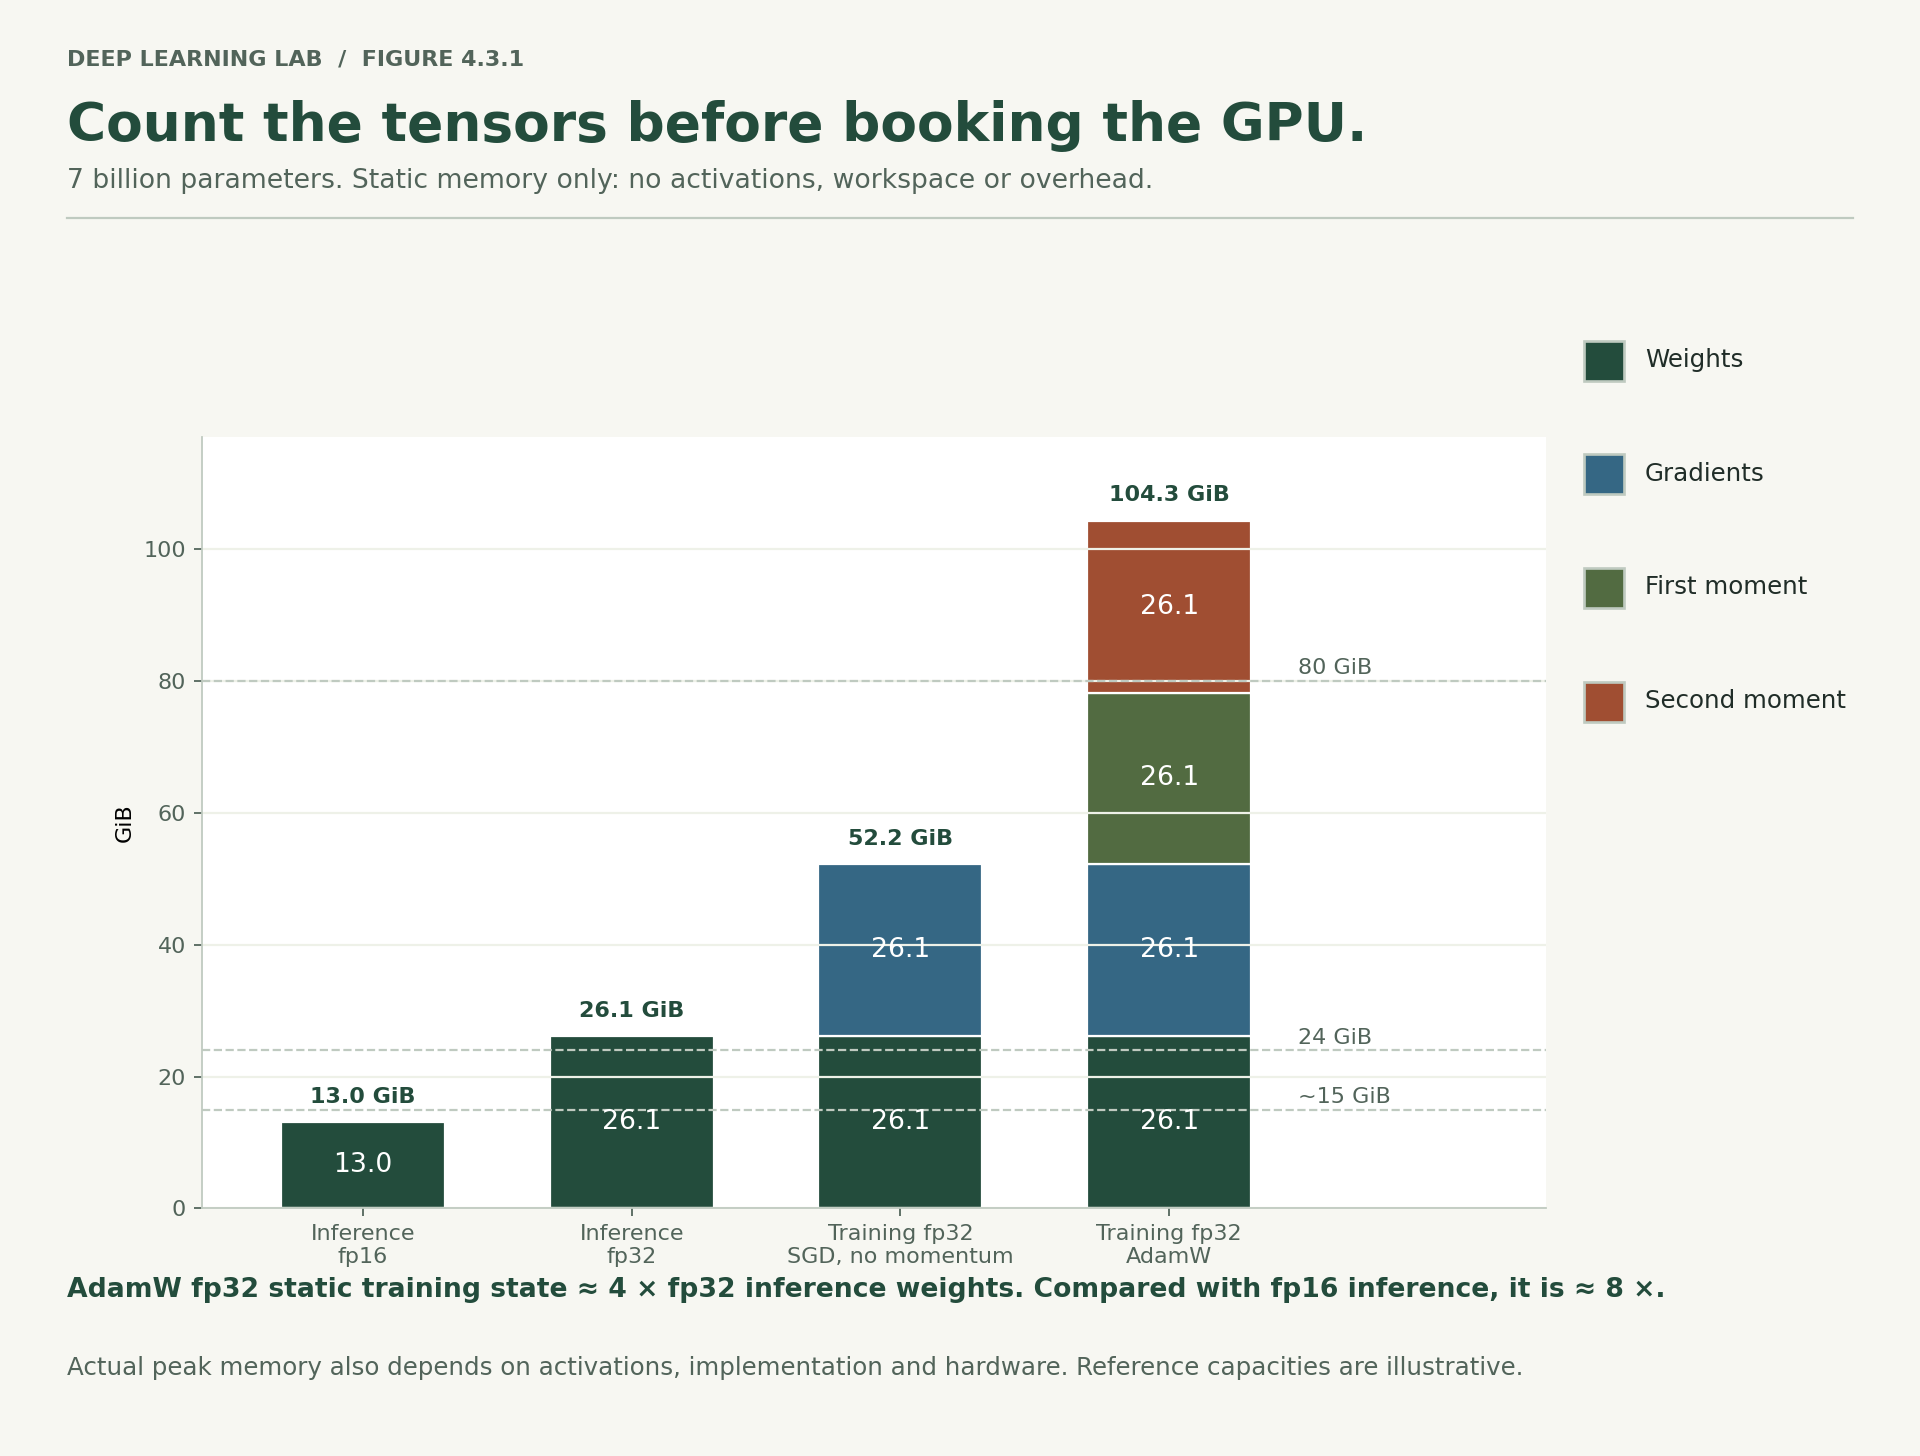

<p><b>Figure 4.3.1.</b> Memory is computed using 2³⁰ bytes per GiB, as in the notebook. Counts omit activations and other overhead; the four-times comparison uses the same fp32 weight precision.</p>

</div>

**Questions to sit with**

1. Using the same logic, estimate the memory needed to fully fine-tune BERT-base with AdamW in fp32.
2. In the LoRA row, why does the total barely fall if you make the adapters even smaller?

<a id="s3"></a>
## 3. fp32, fp16 and bf16

Halving the bytes per number halves three of the four memory terms at once, so the number format is a memory decision before it is a speed decision.

Every one of these formats spends its bits on two different jobs:

- **range** — how big and how small a number it can hold at all;
- **precision** — how finely it can tell nearby numbers apart.

`torch.finfo` reports both.

In [8]:
for number_type in [torch.float32, torch.float16, torch.bfloat16]:
    info = torch.finfo(number_type)
    print(f"{str(number_type):<16} bytes {info.bits // 8}   largest {info.max:>12.3e}   "
          f"smallest normal {info.tiny:.3e}   step near 1.0 {info.eps:.1e}")

torch.float32    bytes 4   largest    3.403e+38   smallest normal 1.175e-38   step near 1.0 1.2e-07
torch.float16    bytes 2   largest    6.550e+04   smallest normal 6.104e-05   step near 1.0 9.8e-04
torch.bfloat16   bytes 2   largest    3.390e+38   smallest normal 1.175e-38   step near 1.0 7.8e-03


In words:

- **fp32** (float32) — 4 bytes. Big range, fine precision. The default everywhere.
- **fp16** (half) — 2 bytes. Precision is decent, but the range is narrow: nothing above 65,504, and nothing usefully small below about 0.00006.
- **bf16** (bfloat16) — 2 bytes. The **same range as fp32**, bought by giving up precision.

Watch both failures happen.

In [9]:
print("too big for fp16:")
print("   70000 in fp32 :", torch.tensor(70000.0).item())
print("   70000 in fp16 :", torch.tensor(70000.0, dtype=torch.float16).item())
print("   70000 in bf16 :", torch.tensor(70000.0, dtype=torch.bfloat16).item())
print()
print("too small for fp16:")
print("   0.00000001 in fp16 :", torch.tensor(1e-8, dtype=torch.float16).item())
print("   0.00000001 in bf16 :", torch.tensor(1e-8, dtype=torch.bfloat16).item())
print()
print("precision, telling 1.0001 from 1:")
print("   1.0001 in fp32 :", torch.tensor(1.0001).item())
print("   1.0001 in fp16 :", torch.tensor(1.0001, dtype=torch.float16).item())
print("   1.0001 in bf16 :", torch.tensor(1.0001, dtype=torch.bfloat16).item())

too big for fp16:
   70000 in fp32 : 70000.0
   70000 in fp16 : inf
   70000 in bf16 : 70144.0

too small for fp16:
   0.00000001 in fp16 : 0.0
   0.00000001 in bf16 : 1.0011717677116394e-08

precision, telling 1.0001 from 1:
   1.0001 in fp32 : 1.000100016593933
   1.0001 in fp16 : 1.0
   1.0001 in bf16 : 1.0


`inf` means the number was too big to represent, so it became infinity. `0.0` means it was too small and vanished. And bf16 cannot tell 1.0001 from 1 at all.

Now the consequence that matters for training. **Gradients are small numbers.** In fp16 many of them fall below that floor and become exactly zero, and a weight whose gradient is zero stops learning. Nothing crashes; the model just quietly trains worse.

The fix is **loss scaling**: multiply the loss by a big constant before the backward pass, so every gradient is multiplied by that constant too and lands inside fp16's range; then divide the gradients by the same constant before the optimizer uses them. `torch.amp.GradScaler` does this and adjusts the constant automatically.

In [10]:
tiny_gradient = 1e-8
scale = 65536.0

print(f"gradient {tiny_gradient} in fp16              :", torch.tensor(tiny_gradient, dtype=torch.float16).item())
print(f"multiplied by {scale:,.0f} first, in fp16 :",
      torch.tensor(tiny_gradient * scale, dtype=torch.float16).item())
print("...then divided back down afterwards:",
      torch.tensor(tiny_gradient * scale, dtype=torch.float16).item() / scale)

gradient 1e-08 in fp16              : 0.0
multiplied by 65,536 first, in fp16 : 0.0006551742553710938
...then divided back down afterwards: 9.997165761888027e-09


Survived. **bf16 needs no scaler**, because its range is fp32's range; that is exactly what it bought with its precision. This is why bf16 is preferred on hardware that supports it.

Which you get depends on the chip. A free Colab T4 has fast fp16 but no hardware bf16. A100, H100 and recent Apple Silicon support bf16. Section 8 checks at runtime instead of assuming.

**Questions to sit with**

1. Why does fp16 need a loss scaler when bf16 does not?
2. bf16 cannot tell 1.0001 from 1.0. Why is that usually harmless while training?

<a id="s4"></a>
## 4. Activations and batch size

Parameters, gradients and optimizer state do not care about batch size. **Activations** do, and that is what makes batch size a memory control.

An **activation** is any intermediate result the forward pass produces and the backward pass will need. Every layer's output is one.

To measure them we use a **forward hook**: a small function PyTorch calls every time a layer produces an output. Ours just adds up the bytes.

In [11]:
def activation_bytes(model, batch_size, n_inputs=50):
    """Total bytes of every layer output in one forward pass."""
    running_total = []

    def record(module, module_input, module_output):
        running_total.append(module_output.numel() * module_output.element_size())

    handles = [layer.register_forward_hook(record) for layer in model]
    with torch.no_grad():
        model(torch.randn(batch_size, n_inputs))
    for handle in handles:
        handle.remove()                 # always remove hooks, or they fire forever
    return sum(running_total)

small_model = build_mlp()
print("activations for one row through the Day 3 network:", activation_bytes(small_model, 1), "bytes")
print("for 256 rows                                     :", activation_bytes(small_model, 256), "bytes")

activations for one row through the Day 3 network: 772 bytes
for 256 rows                                     : 197632 bytes


Exactly 256 times as much. Activation memory is **linear in batch size**: each row costs the same, and you choose how many rows.

On the tiny Day 3 network nobody notices. Use a wider one, where each row costs more, and the picture changes.

In [12]:
wide_model = build_mlp(hidden=(1024, 1024))
wide_parameters = sum(p.numel() for p in wide_model.parameters())

rows = []
for batch_size in [32, 256, 2048, 16384]:
    measured = activation_bytes(wide_model, batch_size)
    rows.append({"batch size": batch_size,
                 "activations (MB)": round(measured / MB, 2),
                 "bytes per row": measured // batch_size,
                 "times the model's weights": round(measured / (wide_parameters * 4), 2)})

print(f"wide network: {wide_parameters:,} parameters = {wide_parameters * 4 / MB:.2f} MB of weights")
print(pd.DataFrame(rows).to_string(index=False))

wide network: 1,102,849 parameters = 4.21 MB of weights
 batch size  activations (MB)  bytes per row  times the model's weights
         32              0.50          16388                       0.12
        256              4.00          16388                       0.95
       2048             32.01          16388                       7.61
      16384            256.06          16388                      60.87


At batch 32 the activations are a rounding error next to the weights. At batch 16,384 they are **61 times** the weights.

That is the trade in one table. Model memory is fixed once you choose an architecture. Activation memory is yours to set, one batch at a time, which is why "halve the batch size" is the first thing to try when a run will not fit.

Two things this simple counting leaves out:

- **Real architectures store more per row.** Attention in a Transformer keeps intermediate results that grow with the *square* of the sequence length, which is why Day 6's talk of context windows is also a conversation about memory.
- **Gradient checkpointing** trades this memory for time: throw activations away during the forward pass and recompute them during the backward pass. It typically saves a large share of activation memory for roughly 30% more compute.

**Questions to sit with**

1. Your model fits at batch 64 and fails at batch 128. Which memory term changed, and which did not?
2. In a Transformer, sequence length behaves like batch size for activation memory, only worse. Why?

<a id="s5"></a>
## 5. Speed and batch size

If small batches save memory, why not always use them? Because every step carries fixed overhead — the Python loop, the optimizer update, the cost of launching work on the hardware — and a tiny batch pays that overhead for very little work.

**Throughput** means rows processed per second. The cell measures it at several batch sizes by running as many steps as fit in one second.

The three warm-up steps matter: the first steps of any timing include one-off costs, so they are run and discarded.

**These numbers belong to the machine that runs the cell.** The shape of the curve is what transfers, not the values.

 batch    rows/second   versus batch 16
    16          2,802              1.0x
    64          8,832              3.2x
   256         16,154              5.8x
  1024         17,629              6.3x
  4096         18,729              6.7x


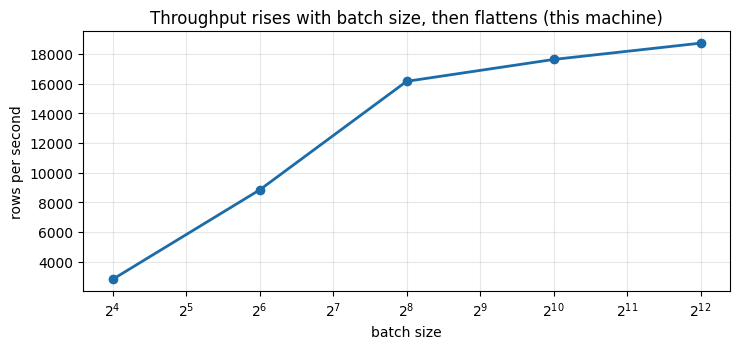

In [13]:
def throughput(model, batch_size, n_inputs=50, seconds=1.0):
    """Rows per second for this batch size on this machine."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    inputs = torch.randn(batch_size, n_inputs)
    targets = (torch.rand(batch_size, 1) > 0.5).float()

    def one_step():
        optimizer.zero_grad()
        loss_function(model(inputs), targets).backward()
        optimizer.step()

    for _ in range(3):
        one_step()                                  # warm up, then discard

    steps, started = 0, time.perf_counter()
    while time.perf_counter() - started < seconds:
        one_step()
        steps += batch_size
    return steps / (time.perf_counter() - started)

torch.manual_seed(0)
bench_model = build_mlp(hidden=(1024, 1024))
batch_sizes = [16, 64, 256, 1024, 4096]
rates = [throughput(bench_model, size) for size in batch_sizes]

print(f"{'batch':>6}  {'rows/second':>13}  {'versus batch 16':>16}")
for size, rate in zip(batch_sizes, rates):
    print(f"{size:>6}  {rate:>13,.0f}  {rate / rates[0]:>15.1f}x")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(batch_sizes, rates, "o-", color="#1b6ca8", lw=2)
ax.set_xscale("log", base=2)
ax.set_xlabel("batch size")
ax.set_ylabel("rows per second")
ax.set_title("Throughput rises with batch size, then flattens (this machine)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The curve climbs steeply and then flattens. Read your own output: on the machine that built this notebook, moving from batch 16 to batch 256 multiplied throughput several times over, moving from 256 to 1,024 added only a little more, and the largest batch was no faster than the one before it.

Past the flat part, a bigger batch buys no speed and costs memory in a straight line. That bend is the useful operating point, and it belongs to the machine rather than the model, so it is worth measuring once on the hardware you really use.

One warning. Batch size is not only an engineering knob. Day 3 showed it changes the training itself: bigger batches give a steadier gradient at each step and usually want a larger learning rate. Shrinking the batch to fit memory and leaving the learning rate alone is a common way to make a model worse for reasons that look mysterious afterwards.

**Questions to sit with**

1. Why does the curve flatten instead of rising forever?
2. You halve the batch size to fit a GPU. What should you consider doing to the learning rate, and why?

<a id="s6"></a>
## 6. Gradient accumulation

Sometimes the batch size you want will not fit at all. **Gradient accumulation** gets it anyway: run several small batches, add their gradients together, and take one optimizer step. Memory follows the small batch. The weight update follows the big one.

There is one subtlety, and it is the usual bug. The loss is an *average* over the rows in the batch, so each small batch's gradient has to be divided by the number of small batches before it is added, or the total comes out too large.

Prove the two are the same.

In [14]:
torch.manual_seed(1)
one_big_batch = build_mlp()
accumulated = build_mlp()
accumulated.load_state_dict(one_big_batch.state_dict())      # identical starting weights

inputs = torch.randn(256, 50)
targets = (torch.rand(256, 1) > 0.5).float()

loss_function(one_big_batch(inputs), targets).backward()      # one batch of 256

for small_x, small_y in zip(inputs.chunk(4), targets.chunk(4)):    # four batches of 64
    (loss_function(accumulated(small_x), small_y) / 4).backward()

biggest_difference = max((a.grad - b.grad).abs().max().item()
                         for a, b in zip(one_big_batch.parameters(), accumulated.parameters()))
print(f"largest difference between the two sets of gradients: {biggest_difference:.2e}")
print()
print("activation memory, batch 256:", f"{activation_bytes(build_mlp(), 256):,} bytes")
print("activation memory, batch  64:", f"{activation_bytes(build_mlp(), 64):,} bytes")

largest difference between the two sets of gradients: 7.45e-09

activation memory, batch 256: 197,632 bytes
activation memory, batch  64: 49,408 bytes


The gradients agree to about 7 in the ninth decimal place, which is ordinary float32 rounding, not a difference in behaviour. And the accumulated version held a quarter of the activations.

Where the equivalence breaks:

- **BatchNorm.** It computes statistics over whatever is in the current small batch, so four batches of 64 normalise differently from one batch of 256. LayerNorm, which Day 6's Transformer block uses, works one row at a time and is unaffected.
- **Forgetting to divide.** Gradients come out four times too big, which behaves exactly like a four-times learning rate. Note 3.4 Case 1 shows what that looks like.
- **Anything else you average inside the loop**, such as a logged metric.

On Day 8 this is a routine setting. Fine-tuning recipes commonly pair a batch of 1 or 2 with 8 to 16 accumulation steps, to get an effective batch of 16 or 32 on one consumer GPU.

**Questions to sit with**

1. You accumulate over 8 small batches and forget to divide. What does the loss curve do?
2. Does gradient accumulation change training time? Memory? The final result?

<a id="s7"></a>
## 7. Mixed precision, and where to put it

**Mixed precision** means running some operations in a smaller number format while keeping the weights themselves in fp32. PyTorch does this with `torch.autocast`, which picks a sensible format per operation: matrix multiplications in bf16 or fp16, and precision-sensitive things like losses in fp32.

On CPU, autocast supports bf16. Time it — remembering that the speed is a property of *this* machine.

In [15]:
def timed_steps(use_autocast, seconds=2.0, batch_size=1024):
    torch.manual_seed(0)
    model = build_mlp(hidden=(1024, 1024))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    inputs = torch.randn(batch_size, 50)
    targets = (torch.rand(batch_size, 1) > 0.5).float()

    def one_step():
        optimizer.zero_grad()
        with torch.autocast("cpu", dtype=torch.bfloat16, enabled=use_autocast):
            output = model(inputs)
        loss_function(output.float(), targets).backward()
        optimizer.step()

    for _ in range(3):
        one_step()
    steps, started = 0, time.perf_counter()
    while time.perf_counter() - started < seconds:
        one_step()
        steps += 1
    return steps / (time.perf_counter() - started)

fp32_rate = timed_steps(False)
bf16_rate = timed_steps(True)
print(f"fp32           : {fp32_rate:6.1f} steps per second")
print(f"autocast bf16  : {bf16_rate:6.1f} steps per second   ({bf16_rate / fp32_rate:.2f}x)")

fp32           :   20.0 steps per second
autocast bf16  :   68.2 steps per second   (3.41x)


In [16]:
demo = build_mlp(hidden=(1024, 1024))
with torch.autocast("cpu", dtype=torch.bfloat16):
    output = demo(torch.randn(8, 50))

print("inside autocast, the layer output is:", output.dtype)
print("but the weights are still           :", next(demo.parameters()).dtype)

inside autocast, the layer output is: torch.bfloat16
but the weights are still           : torch.float32


Note what autocast does **not** do. The weights stay fp32. Only the operations run in the smaller format, and the results come back smaller. So the memory saving is in the activations, not in the model.

On the machine that built this notebook, bf16 ran roughly three times as many steps per second. On yours it may be slower, especially on a CPU without bf16 instructions. **Speed from mixed precision is a hardware property, not a free gift.** Measure it on the device you will really train on. The memory saving, by contrast, is arithmetic, and is always there.

### Does it change the answer?

Check against a result you already know: the Bank Marketing model from Notes 4.1 and 4.2. First the data, in three compressed cells.

In [17]:
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
BANK_CSV = "data/bank-full.csv"

def load_bank_marketing(path=BANK_CSV):
    if not os.path.exists(path):
        raw_bytes = urllib.request.urlopen(BANK_URL, timeout=120).read()
        outer = zipfile.ZipFile(io.BytesIO(raw_bytes))
        inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, "wb") as f:
            f.write(inner.read("bank-full.csv"))
    df = pd.read_csv(path, sep=";")
    y = (df["y"] == "yes").astype(np.float32).to_numpy()
    return df.drop(columns=["y", "duration"]), y

from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X, y = load_bank_marketing()
rows = np.arange(len(y))
train_rows, rest = train_test_split(rows, train_size=0.8, random_state=42, stratify=y)
val_rows, test_rows = train_test_split(rest, test_size=0.5, random_state=42, stratify=y[rest])

numeric = X.select_dtypes(include="number").columns.tolist()
categorical = [c for c in X.columns if c not in numeric]
preprocessor = ColumnTransformer([
    ("scale", StandardScaler(), numeric),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
]).fit(X.iloc[train_rows])

train_inputs = torch.tensor(preprocessor.transform(X.iloc[train_rows]).astype(np.float32))
train_targets = torch.tensor(y[train_rows]).unsqueeze(1)
val_inputs = torch.tensor(preprocessor.transform(X.iloc[val_rows]).astype(np.float32))
val_targets = y[val_rows]

print("training rows:", train_inputs.shape, "| validation rows:", val_inputs.shape)

training rows: torch.Size([36168, 50]) | validation rows: torch.Size([4521, 50])


Now one training function with three settings, so we can put autocast in different places and compare:

- `"fp32"` — no autocast at all;
- `"forward"` — autocast around the forward pass only, which is how it is meant to be used;
- `"whole"` — autocast wrapped around the entire training loop, which looks tidier and is the mistake.

In [18]:
def train_bank(mode="fp32", epochs=10, cache_enabled=True, seed=42):
    torch.manual_seed(seed)
    model = build_mlp(n_inputs=train_inputs.shape[1])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    generator = torch.Generator().manual_seed(seed)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_inputs, train_targets),
        batch_size=256, shuffle=True, generator=generator)

    def one_epoch():
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            with torch.autocast("cpu", dtype=torch.bfloat16, enabled=(mode == "forward")):
                output = model(batch_x)
            loss_function(output.float(), batch_y).backward()
            optimizer.step()

    def validation_auc():
        model.eval()
        with torch.no_grad():
            probabilities = torch.sigmoid(model(val_inputs).float()).numpy().ravel()
        return roc_auc_score(val_targets, probabilities)

    best = 0.0
    if mode == "whole":
        with torch.autocast("cpu", dtype=torch.bfloat16, cache_enabled=cache_enabled):
            for _ in range(epochs):
                one_epoch()
                best = max(best, validation_auc())
    else:
        for _ in range(epochs):
            one_epoch()
            best = max(best, validation_auc())
    return best

print(f"fp32, no autocast                        : best validation AUC {train_bank('fp32'):.4f}")
print(f"autocast around the forward pass         : best validation AUC {train_bank('forward'):.4f}")
print(f"autocast around the whole training loop  : best validation AUC {train_bank('whole'):.4f}")
print(f"the same, with cache_enabled=False       : best validation AUC {train_bank('whole', cache_enabled=False):.4f}")

fp32, no autocast                        : best validation AUC 0.7847


autocast around the forward pass         : best validation AUC 0.7847


autocast around the whole training loop  : best validation AUC 0.7584


the same, with cache_enabled=False       : best validation AUC 0.7848


Read those four lines carefully, because the third one is the lesson.

The first two are **identical to four decimal places: 0.7847**. Running the forward pass in bf16 cost this model nothing.

The third dropped to **0.7584**. The fourth, differing only by `cache_enabled=False`, came back to **0.7848**.

So this is not a precision problem at all. It is a **caching** problem. Inside an autocast block, PyTorch caches the reduced-precision copies it makes of your fp32 weights, so that a weight used by several operations is converted once rather than repeatedly. That cache is designed for a block covering **one forward pass**. Stretch the block across many optimizer steps and the model keeps reusing copies made from older weights, so part of the network is training on stale values. Nothing errors. The loss curve looks plausible.

**Put autocast around the forward pass, not around the loop.** In an earlier draft of this note the block wrapped an entire 30-epoch run including the scoring, and validation AUC fell to 0.4079 — worse than guessing, a collapse that looks exactly like Note 3.4 Case 1 but has a completely different cause.

One more consequence, following from Note 4.2: mixed precision costs you bit-for-bit repeatability, because the arithmetic itself has changed. The run is still reproducible at Level 2, as long as the record says which precision was used. Make it a setting in your config rather than a switch you flip by hand.

**Questions to sit with**

1. Autocast leaves the weights in fp32. Which of the four memory terms does it actually reduce?
2. Why should you not expect a bf16 run to reproduce an fp32 run to the last decimal?

<a id="s8"></a>
## 8. On an NVIDIA GPU: VRAM, running out, and recovering

Everything so far was arithmetic that holds anywhere. Three things are specific to an NVIDIA GPU, and these cells run only if one is present: reading how much GPU memory is actually in use, meeting a real out-of-memory error, and training in fp16 with a loss scaler.

**VRAM** is the GPU's own memory, separate from your computer's RAM. It is usually much smaller: 15 GB on a free Colab T4, against 16 GB or more of ordinary RAM on a laptop.

**If you are on a laptop, run this section on a free Colab or Kaggle GPU.** It is the same code; the cells below detect the machine and skip. Day 8's QLoRA work and Day 9's serving work need an NVIDIA GPU too, so it is worth doing once now, while the code is short enough to read.

Start with the recovery ladder, which is not GPU-specific logic at all and so can be tested anywhere: try the batch size you want; if it fails with an out-of-memory error, clean up and halve it.

In [19]:
OUT_OF_MEMORY = (torch.OutOfMemoryError, torch.cuda.OutOfMemoryError)

def largest_batch_that_fits(attempt, start, smallest=1, errors=OUT_OF_MEMORY):
    """Halve the batch size until the attempt succeeds. Returns the size and the log."""
    size, log = start, []
    while size >= smallest:
        try:
            attempt(size)
            log.append((size, "fits"))
            return size, log
        except errors:
            log.append((size, "out of memory"))
            gc.collect()                                  # let Python release the tensors
            if torch.cuda.is_available():
                torch.cuda.empty_cache()                  # hand the memory back to the driver
            size //= 2
    return None, log

class PretendOutOfMemory(Exception):
    pass

def pretend_gpu(batch_size, limit=512):
    """Stands in for a real training step, so the ladder can be tested on any machine."""
    if batch_size > limit:
        raise PretendOutOfMemory(f"pretend out of memory at batch {batch_size}")

found, log = largest_batch_that_fits(pretend_gpu, start=4096, errors=(PretendOutOfMemory,))
for size, outcome in log:
    print(f"  batch {size:>5} -> {outcome}")
print(f"largest batch that fits: {found}")

  batch  4096 -> out of memory
  batch  2048 -> out of memory
  batch  1024 -> out of memory
  batch   512 -> fits
largest batch that fits: 512


On a GPU you pass the real training step and the real error type instead of the pretend ones. That is what the next cells do.

In [20]:
if DEVICE.type != "cuda":
    print("No NVIDIA GPU here, so this cell is skipped.")
    print("Run this notebook on Colab or Kaggle with a GPU runtime to see the numbers.")
else:
    properties = torch.cuda.get_device_properties(0)
    free, total = torch.cuda.mem_get_info()
    print(f"GPU                        : {properties.name}")
    print(f"total VRAM                 : {total / GB:.2f} GB")
    print(f"free right now             : {free / GB:.2f} GB")
    print(f"bf16 supported in hardware : {torch.cuda.is_bf16_supported()}")
    print(f"currently held by torch    : {torch.cuda.memory_allocated() / MB:.1f} MB")

No NVIDIA GPU here, so this cell is skipped.
Run this notebook on Colab or Kaggle with a GPU runtime to see the numbers.


In [21]:
if DEVICE.type != "cuda":
    print("Skipped: needs an NVIDIA GPU.")
else:
    gpu_model = build_mlp(hidden=(4096, 4096)).cuda()
    gpu_optimizer = torch.optim.AdamW(gpu_model.parameters(), lr=1e-3)

    def one_gpu_step(batch_size):
        inputs = torch.randn(batch_size, 50, device="cuda")
        targets = (torch.rand(batch_size, 1, device="cuda") > 0.5).float()
        gpu_optimizer.zero_grad()
        loss_function(gpu_model(inputs), targets).backward()
        gpu_optimizer.step()

    rows = []
    for batch_size in [256, 1024, 4096, 16384]:
        torch.cuda.reset_peak_memory_stats()          # start the high-water mark again
        try:
            one_gpu_step(batch_size)
            rows.append({"batch size": batch_size,
                         "peak VRAM (MB)": round(torch.cuda.max_memory_allocated() / MB, 1),
                         "result": "fits"})
        except OUT_OF_MEMORY:
            rows.append({"batch size": batch_size, "peak VRAM (MB)": None, "result": "out of memory"})
            gc.collect()
            torch.cuda.empty_cache()
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nthe weights alone:",
          round(sum(p.numel() for p in gpu_model.parameters()) * 4 / MB, 1), "MB")

Skipped: needs an NVIDIA GPU.


In [22]:
if DEVICE.type != "cuda":
    print("Skipped: needs an NVIDIA GPU. On a GPU this fills the memory on purpose and recovers.")
else:
    blocks = []
    free_at_start, _ = torch.cuda.mem_get_info()
    try:
        while True:                                   # grab 512 MB at a time until it fails
            blocks.append(torch.empty(int(512 * MB // 4), dtype=torch.float32, device="cuda"))
    except OUT_OF_MEMORY as error:
        print("caught:", str(error).split("\n")[0][:110])

    print(f"blocks allocated before it failed : {len(blocks)} ({len(blocks) * 512 / 1024:.1f} GB)")
    print(f"free VRAM now                     : {torch.cuda.mem_get_info()[0] / MB:.0f} MB")

    del blocks                                        # the recovery, in order
    gc.collect()
    torch.cuda.empty_cache()
    print(f"free VRAM after cleaning up       : {torch.cuda.mem_get_info()[0] / MB:.0f} MB "
          f"(it started at {free_at_start / MB:.0f} MB)")

Skipped: needs an NVIDIA GPU. On a GPU this fills the memory on purpose and recovers.


Three details in that recovery are worth remembering.

**`del` on its own is not enough.** Python releases the tensor, but PyTorch keeps the memory in its own pool to reuse later, so a tool like `nvidia-smi` still shows it as used. `torch.cuda.empty_cache()` gives it back to the driver. That matters when another process needs it; inside your own process the pool is a feature, not a leak.

**A caught error can keep your memory alive.** An exception carries a traceback, and the traceback holds every local variable in every function it passed through — including the huge tensors that caused the failure. In a notebook the variables from the failed cell survive too. Restarting the kernel after a bad out-of-memory error is not superstition.

**`nvidia-smi` and `torch.cuda.memory_allocated()` measure different things.** The first shows what the process has reserved from the driver; the second shows what your tensors are actually using. A large gap between them is the pool, not a leak.

Finally, fp16 training with the loss scaler from Section 3.

In [23]:
if DEVICE.type != "cuda":
    print("Skipped: needs an NVIDIA GPU. The pattern below is the one to reuse on Colab or Kaggle.")
else:
    amp_model = build_mlp(hidden=(1024, 1024)).cuda()
    amp_optimizer = torch.optim.AdamW(amp_model.parameters(), lr=1e-3)
    scaler = torch.amp.GradScaler("cuda")
    inputs = torch.randn(4096, 50, device="cuda")
    targets = (torch.rand(4096, 1, device="cuda") > 0.5).float()

    for step in range(5):
        amp_optimizer.zero_grad()
        with torch.autocast("cuda", dtype=torch.float16):     # forward pass only
            loss = loss_function(amp_model(inputs), targets)
        scaler.scale(loss).backward()      # multiply the loss up, then go backward
        scaler.step(amp_optimizer)         # divide the gradients back down, then step
        scaler.update()                    # adjust the multiplier for next time

    print(f"five fp16 steps done. final loss {loss.item():.4f}, "
          f"loss multiplier now {scaler.get_scale():,.0f}")
    print("on bf16-capable hardware the same loop with dtype=torch.bfloat16 needs no scaler")

Skipped: needs an NVIDIA GPU. The pattern below is the one to reuse on Colab or Kaggle.


`scaler.step()` sometimes skips the optimizer step entirely. That happens when a gradient overflowed to infinity, in which case the step would be meaningless, so it is thrown away and the multiplier is lowered. Skipping a step occasionally is the correct behaviour, not a bug.

**Questions to sit with**

1. Why does `nvidia-smi` still show memory in use after `del tensor`?
2. You get an out-of-memory error at batch 64 that did not happen yesterday with the same code. Name three things that could have changed.

<a id="s9"></a>
## 9. On an Apple Silicon Mac

**MPS** is PyTorch's backend for the graphics processor built into Apple Silicon chips (M1 through M5). Two differences from an NVIDIA GPU matter here.

**Memory is unified.** The graphics processor shares the machine's RAM rather than having its own separate VRAM. So there is no separate memory figure to read, and no clean wall to hit. An oversized job tends to push the whole machine into swapping and slow everything down, rather than raising a tidy error. **That is why this note does not include a deliberate out-of-memory demonstration for MPS.** Raise batch sizes gradually and watch memory pressure in Activity Monitor.

**Coverage is good but not complete.** An operation with no MPS implementation raises an error, unless you set `PYTORCH_ENABLE_MPS_FALLBACK=1`, which quietly runs it on the CPU instead. That is correct but sometimes much slower than staying on the CPU for the whole job.

Worth planning around: **bitsandbytes, vLLM and flash-attention are NVIDIA-only.** Day 8's QLoRA work and Day 9's serving work go to Colab or Kaggle. Day 8 has a LoRA-only path that does run on a Mac.

In [24]:
if DEVICE.type != "mps":
    print("No Apple Silicon GPU here, so this cell is skipped.")
    print("On a Mac it reports unified memory use and checks which autocast types work.")
else:
    print(f"memory torch is allowed to use : {torch.mps.recommended_max_memory() / GB:.2f} GB")
    print(f"currently held by torch        : {torch.mps.current_allocated_memory() / MB:.1f} MB")
    print(f"reserved from the system       : {torch.mps.driver_allocated_memory() / MB:.1f} MB")

    mps_model = build_mlp(hidden=(1024, 1024)).to("mps")
    mps_optimizer = torch.optim.AdamW(mps_model.parameters(), lr=1e-3)
    inputs = torch.randn(4096, 50, device="mps")
    targets = (torch.rand(4096, 1, device="mps") > 0.5).float()
    for _ in range(3):
        mps_optimizer.zero_grad()
        loss_function(mps_model(inputs), targets).backward()
        mps_optimizer.step()
    torch.mps.synchronize()                 # wait for the GPU to actually finish
    print(f"after three steps, held by torch: {torch.mps.current_allocated_memory() / MB:.1f} MB")

    for number_type in (torch.float16, torch.bfloat16):
        try:
            with torch.autocast("mps", dtype=number_type):
                output = mps_model(inputs[:8])
            print(f"autocast {str(number_type):<18}: works, output {output.dtype}")
        except (RuntimeError, TypeError) as error:
            print(f"autocast {str(number_type):<18}: not supported here ({str(error)[:60]})")
    torch.mps.empty_cache()

No Apple Silicon GPU here, so this cell is skipped.
On a Mac it reports unified memory use and checks which autocast types work.


<a id="s10"></a>
## 10. The out-of-memory playbook

Note 3.4 ordered its checks by cost, cheapest first. The same discipline applies here, because these fixes differ enormously in what they cost you.

**Tier 0 — free, and changes nothing about the model**

1. **Restart the kernel or the process.** Clears dead tensors held alive by tracebacks and by old notebook state.
2. **Check you are not keeping tensors alive by accident.** Appending `loss` to a list instead of `loss.item()` keeps the entire computation graph for that batch, epoch after epoch. It looks like a slow leak and it is the commonest cause.
3. **Wrap scoring in `torch.no_grad()`.** Without it, evaluation stores activations for a backward pass that never comes.
4. **Free what you no longer need**: `del`, then `gc.collect()`, then `empty_cache()`.

**Tier 1 — cheap, changes the run but not the model**

5. **Halve the batch size**, and use the ladder from Section 8 to find the largest that fits.
6. **Add gradient accumulation** to get the effective batch back, as in Section 6.
7. **Turn on mixed precision.** Halves the activations, and may help speed if the hardware supports it.
8. **Shorten the sequence length** if you are working with text. The cost grows faster than linearly.

**Tier 2 — changes the computation or the model**

9. **Gradient checkpointing**: recompute activations instead of storing them, at roughly 30% more time.
10. **Freeze most of the model**, training only a head or small adapters. This is where LoRA belongs, and it removes gradients and optimizer state for everything frozen (Day 8).
11. **Quantise the frozen weights**, which is QLoRA on Day 8, or quantise for serving on Day 9.
12. **A smaller model, or a bigger GPU.** Last, not first, because both cost money or accuracy.

Work down the list. Most people start at 12, or at 5 with a guess. The first four cost nothing and fix a surprising share of real failures.

<div align="center">

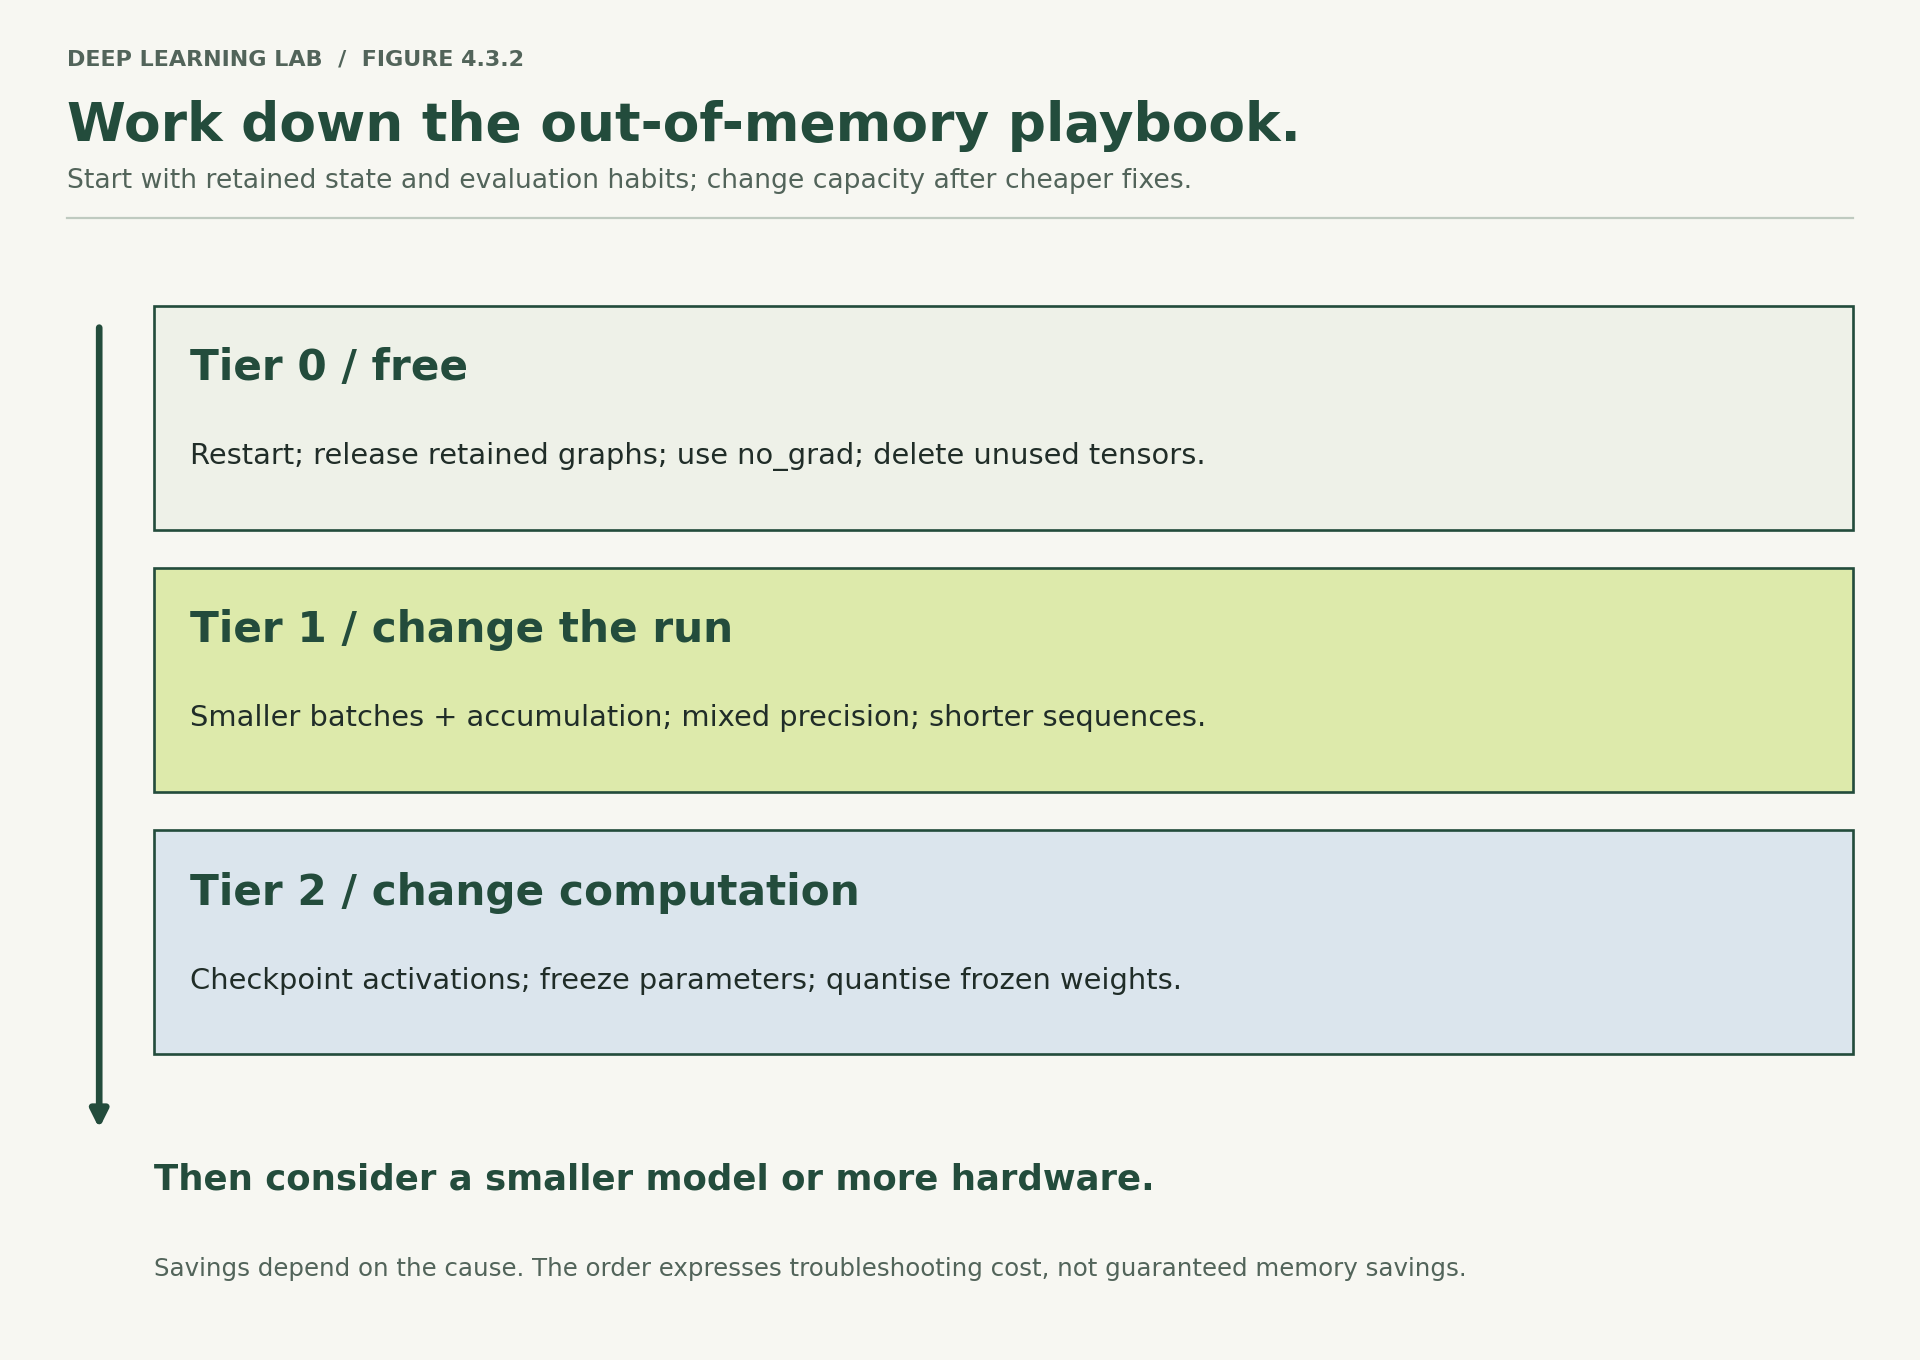

<p><b>Figure 4.3.2.</b> The lesson’s troubleshooting order: eliminate needless retained state, change the run, then change computation or capacity. Savings are workload-dependent.</p>

</div>

### What to take away

**Training with AdamW needs about four times the model's own memory**, before a single activation: weights, gradients, and two running averages. That factor is the reason Day 8 exists.

**You can predict memory before running anything.** Parameter count, times bytes per number, times the optimizer's copies. The 7B rows in Section 2 show why running such a model and training it sit on opposite sides of a hardware boundary.

**Precision is a trade between range and fineness.** bf16 keeps fp32's range and needs no loss scaler; fp16 keeps more fineness but its narrow range means gradients vanish without one.

**Activations are the batch-dependent term**, linear in batch size and constant per row. So batch size is the fastest memory control you have, and gradient accumulation gives back the effective batch you gave up.

**Speed from mixed precision is a hardware property; the memory saving is arithmetic.** Measure the first, count on the second.

**Put autocast around the forward pass.** Wrapping the whole loop cost 0.026 AUC here, silently, because of a weight cache that was never meant to live that long.

**An out-of-memory error has a playbook.** Restart, look for retained graphs, use `no_grad`, then batch size and accumulation, then checkpointing and freezing. Hardware last.

### Transition to Note 4.4

You now have three of the four pieces of a defensible experiment: data you can trust (4.1), a run that records itself and can be repeated (4.2), and a clear idea of what a run costs in memory (4.3).

Note 4.4 spends them. A gradient-boosting model and the Day 3 neural network compete on Bank Marketing, on identical splits, with the tuning budget written down in advance and every claim checked against the noise you measured in 4.2. The blueprint's instruction for that contest is explicit: the conclusion is not allowed to be "neural networks win". It has to be a decision you could defend to somebody who disagrees with you.